# PACU Staffing Risk Simulation

## Decision Question

When PACU is short-staffed to 3 bays, how can perioperative leaders use the scheduled case pattern to decide whether temporary staffing should be activated before capacity pressure occurs?

## Approach

This analysis uses historical PACU arrival times and length-of-stay data to:

- characterize baseline PACU demand,
- select a high-volume schedule for stress testing,
- simulate variation in PACU length of stay using Monte Carlo resampling,
- estimate the probability and severity of demand exceeding 3 staffed bays, and
- define a practical simulation-based staffing trigger.

The primary decision rule is based on schedule-specific simulated over-capacity risk. Daily case count is evaluated separately as an early screening signal.

## Access and Load Data through BigQuery

In [ ]:
from google.colab import auth
from google.cloud import bigquery
from tqdm.notebook import tqdm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

DATA_PROJECT_ID = "healthcare-analytics-lab"
DATASET_ID = "demo_hospital_system"

# GCP project used to execute BigQuery queries
QUERY_PROJECT_ID = "502860847904"

auth.authenticate_user()
client = bigquery.Client(project=QUERY_PROJECT_ID)


In [ ]:
# Test connection to the primary analysis table

connection_test_query = """
SELECT
  COUNT(*) AS row_count
FROM `healthcare-analytics-lab.demo_hospital_system.or_encounter`
"""

query_job = client.query(connection_test_query)
results = query_job.result()

for row in results:
    print(f"or_encounter rows: {row.row_count:,}")

or_encounter rows: 1,034


In [ ]:
# Create Pandas dataframe from query

# Import the OR encounter table used for PACU analysis
or_query = """
SELECT *
FROM `healthcare-analytics-lab.demo_hospital_system.or_encounter`
"""

or_rows = client.query(or_query).result()
or_df = pd.DataFrame([dict(row) for row in or_rows])

In [ ]:
print(or_df.info())
print("\n")
or_df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1034 entries, 0 to 1033
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   or_case_id                 1034 non-null   object             
 1   or_pat_id                  1034 non-null   object             
 2   or_csn                     1034 non-null   object             
 3   or_procedure_icd_10_code   1034 non-null   object             
 4   or_procedure_name          1034 non-null   object             
 5   or_surgeon_id              1034 non-null   object             
 6   or_surgeon_name            1034 non-null   object             
 7   or_surgeon_specialty       1034 non-null   object             
 8   or_arrival_dttm            1034 non-null   datetime64[ns, UTC]
 9   or_procedure_start_dttm    1034 non-null   datetime64[ns, UTC]
 10  or_procedure_end_dttm      1034 non-null   datetime64[ns, UTC]
 11  or_p

,or_case_id,or_pat_id,or_csn,or_procedure_icd_10_code,or_procedure_name,or_surgeon_id,or_surgeon_name,or_surgeon_specialty,or_arrival_dttm,or_procedure_start_dttm,or_procedure_end_dttm,or_pacu_arrival_dttm,or_pacu_discharge_dttm,or_case_type,or_primary_operating_team
0,or_case000354,pat00061,hsp000471,0DTJ0ZZ,laparoscopic_appendectomy,general_surgery_md_01,general surgery_63,general_surgery,2024-01-09 15:13:00+00:00,2024-01-09 15:45:00+00:00,2024-01-09 16:20:00+00:00,2024-01-09 16:42:00+00:00,2024-01-09 17:47:00+00:00,urgent,general_surgery_team
1,or_case000374,pat00577,hsp001335,0YQA0ZZ,inguinal_hernia_repair,general_surgery_md_07,general surgery_14,general_surgery,2024-01-09 12:45:00+00:00,2024-01-09 13:06:00+00:00,2024-01-09 15:02:00+00:00,2024-01-09 15:16:00+00:00,2024-01-09 16:38:00+00:00,urgent,general_surgery_team
2,or_case001000,pat00713,hsp000707,0FB40ZZ,laparoscopic_cholecystectomy,general_surgery_md_05,general surgery_23,general_surgery,2024-01-09 14:13:00+00:00,2024-01-09 14:39:00+00:00,2024-01-09 15:27:00+00:00,2024-01-09 15:47:00+00:00,2024-01-09 17:27:00+00:00,urgent,general_surgery_team
3,or_case000287,pat00634,hsp000583,0YQA0ZZ,inguinal_hernia_repair,general_surgery_md_05,general surgery_59,general_surgery,2024-10-27 08:37:00+00:00,2024-10-27 09:05:00+00:00,2024-10-27 10:28:00+00:00,2024-10-27 10:42:00+00:00,2024-10-27 12:57:00+00:00,elective,general_surgery_team
4,or_case000161,pat00700,hsp000402,0DTJ0ZZ,laparoscopic_appendectomy,general_surgery_md_03,general surgery_12,general_surgery,2024-10-27 13:12:00+00:00,2024-10-27 13:59:00+00:00,2024-10-27 14:53:00+00:00,2024-10-27 15:14:00+00:00,2024-10-27 17:03:00+00:00,urgent,general_surgery_team


### PACU LOS validation

PACU LOS was calculated as the difference between `or_pacu_discharge_dttm`
and `or_pacu_arrival_dttm`, measured in minutes.

In the loaded `or_encounter` table, there were 1,034 OR cases with complete
PACU arrival and discharge timestamps. The observed PACU LOS distribution had:

- Median PACU LOS: 97.0 minutes
- P90 PACU LOS: 171.7 minutes

**Dataset version note:** The assignment materials cite a local-dataset reference of approximately 81 minutes for median PACU LOS and 135 minutes for P90 PACU LOS. This notebook queries the course BigQuery `or_encounter` table directly. The queried table returned 1,034 OR cases and produced a median PACU LOS of 97.0 minutes and P90 PACU LOS of 171.7 minutes; therefore, the analysis and simulation below use the PACU LOS distribution observed in the directly queried BigQuery data.

The course data dictionary distinguishes between the BigQuery/schema population and the local CSV profile, so differences between the local reference statistics and the queried dataset are documented rather than manually reconciled.

**Timestamp assumption:** Calendar dates and hours are derived directly from the timestamps supplied by the course dataset. No additional timezone conversion is applied.


In [ ]:
or_df["pacu_los_minutes"] = (or_df['or_pacu_discharge_dttm'] - or_df['or_pacu_arrival_dttm']).dt.total_seconds() / 60

median_los = or_df["pacu_los_minutes"].median()
p90_los = or_df["pacu_los_minutes"].quantile(0.90)

print(f"Median pacu_los_minutes: {median_los:.2f} minutes")
print(f"90th Percentile pacu_los_minutes: {p90_los:.2f} minutes")
print("Negative LOS:", (or_df["pacu_los_minutes"] < 0).sum())
print("Zero LOS:", (or_df["pacu_los_minutes"] == 0).sum())
print("Very long LOS > 6 hours:", (or_df["pacu_los_minutes"] > 360).sum())
print('\nData Distribution of PACU LOS')
print(or_df["pacu_los_minutes"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

Median pacu_los_minutes: 97.00 minutes
90th Percentile pacu_los_minutes: 171.70 minutes
Negative LOS: 0
Zero LOS: 0
Very long LOS > 6 hours: 0

Data Distribution of PACU LOS
count    1034.000000
mean      101.465184
std        49.298283
min        20.000000
25%        63.000000
50%        97.000000
75%       128.000000
90%       171.700000
95%       201.700000
99%       232.670000
max       240.000000
Name: pacu_los_minutes, dtype: float64


## Baseline PACU Demand

### PACU Length of Stay

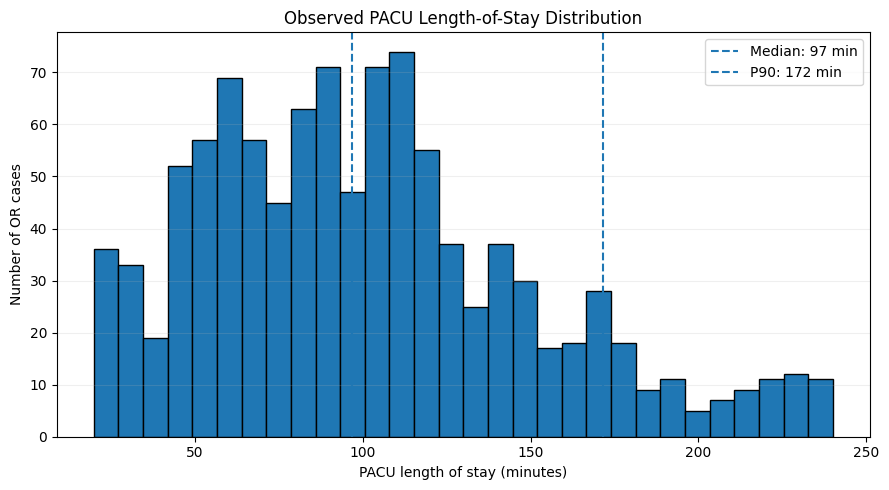

In [ ]:
los_median = or_df["pacu_los_minutes"].median()
los_p90 = or_df["pacu_los_minutes"].quantile(0.90)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    or_df["pacu_los_minutes"],
    bins=30,
    edgecolor="black"
)

ax.axvline(
    los_median,
    linestyle="--",
    label=f"Median: {los_median:.0f} min"
)

ax.axvline(
    los_p90,
    linestyle="--",
    label=f"P90: {los_p90:.0f} min"
)

ax.set_title("Observed PACU Length-of-Stay Distribution")
ax.set_xlabel("PACU length of stay (minutes)")
ax.set_ylabel("Number of OR cases")

ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

### Daily PACU Case Volume

In [ ]:
or_df["pacu_arrival_date"] = or_df["or_pacu_arrival_dttm"].dt.date

In [ ]:
# Cases per PACU arrival day
daily_case_counts = (
    or_df
    .groupby("pacu_arrival_date")
    .size()
    .reset_index(name="case_count")
)

print(daily_case_counts["case_count"].describe())

count    341.000000
mean       3.032258
std        1.724090
min        1.000000
25%        2.000000
50%        3.000000
75%        4.000000
max       10.000000
Name: case_count, dtype: float64


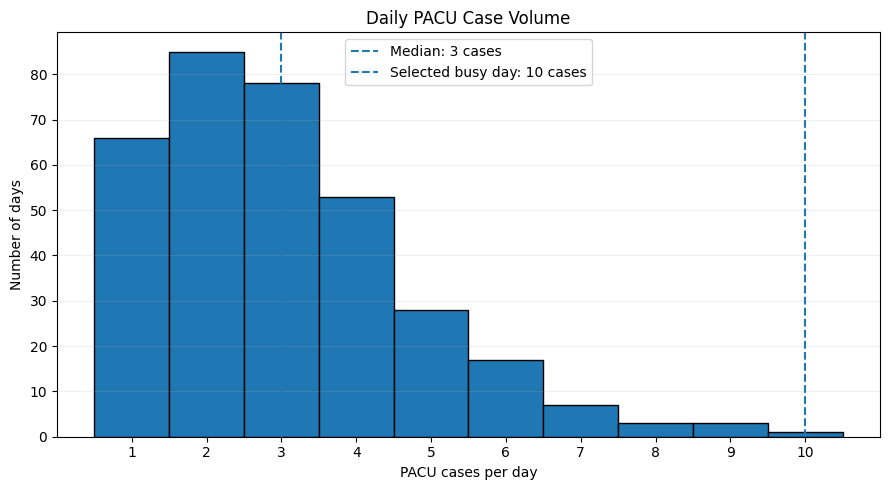

In [ ]:
case_min = int(daily_case_counts["case_count"].min())
case_max = int(daily_case_counts["case_count"].max())
median_cases = daily_case_counts["case_count"].median()

bins = np.arange(case_min - 0.5, case_max + 1.5, 1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    daily_case_counts["case_count"],
    bins=bins,
    edgecolor="black"
)

ax.axvline(
    median_cases,
    linestyle="--",
    label=f"Median: {median_cases:.0f} cases"
)

ax.axvline(
    case_max,
    linestyle="--",
    label=f"Selected busy day: {case_max} cases"
)

ax.set_title("Daily PACU Case Volume")
ax.set_xlabel("PACU cases per day")
ax.set_ylabel("Number of days")

ax.set_xticks(range(case_min, case_max + 1))
ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

## Busy-Day Selection and Observed Demand



In [ ]:
busiest_days = daily_case_counts.sort_values(
    "case_count",
    ascending=False
).reset_index(drop=True)

busiest_days.head(10)

,pacu_arrival_date,case_count
0,2024-03-30,10
1,2024-02-23,9
2,2024-05-21,9
3,2024-03-14,9
4,2024-09-30,8
5,2024-06-10,8
6,2024-04-05,8
7,2024-10-31,7
8,2024-11-02,7
9,2024-05-13,7


In [ ]:
busy_day = busiest_days.iloc[0]["pacu_arrival_date"]

busy_day_df = or_df[or_df["pacu_arrival_date"] == busy_day].copy()


print("Selected busy day:", busy_day)
print("Case count:", len(busy_day_df))

Selected busy day: 2024-03-30
Case count: 10


### Busy-day selection

I selected the PACU day with the highest observed number of PACU arrivals in the `or_encounter` table. This schedule provides a useful stress-test case because a high-volume day with clustered PACU arrivals creates a meaningful test of short-staffed 3-bay capacity.

The selected day was March 30, 2024, with 10 PACU arrivals. I used the observed PACU arrival times from this day as the fixed schedule for the simulation, then resampled PACU LOS values from the full observed PACU LOS distribution.


### Observed Occupancy Definition

A case contributes to PACU demand at time \(t\) when:

**PACU arrival ≤ \(t\) < PACU discharge**

Using this definition, occupancy is reconstructed at one-minute intervals for the selected busy day. This provides a baseline check of how the recorded case schedule overlaps before introducing simulated LOS variation.

In [ ]:
arrival_col = "or_pacu_arrival_dttm"
discharge_col = "or_pacu_discharge_dttm"

start_time = busy_day_df[arrival_col].min().floor("h")
end_time = busy_day_df[discharge_col].max().ceil("h")

timeline = pd.date_range(start=start_time, end=end_time, freq="1min")

occupancy = []

for t in timeline:
    occ = (
        (busy_day_df[arrival_col] <= t) &
        (busy_day_df[discharge_col] > t)
    ).sum()
    occupancy.append(occ)

observed_occupancy = pd.DataFrame({
    "time": timeline,
    "occupancy": occupancy
})

observed_occupancy.head()

,time,occupancy
0,2024-03-30 09:00:00+00:00,0
1,2024-03-30 09:01:00+00:00,0
2,2024-03-30 09:02:00+00:00,0
3,2024-03-30 09:03:00+00:00,0
4,2024-03-30 09:04:00+00:00,0


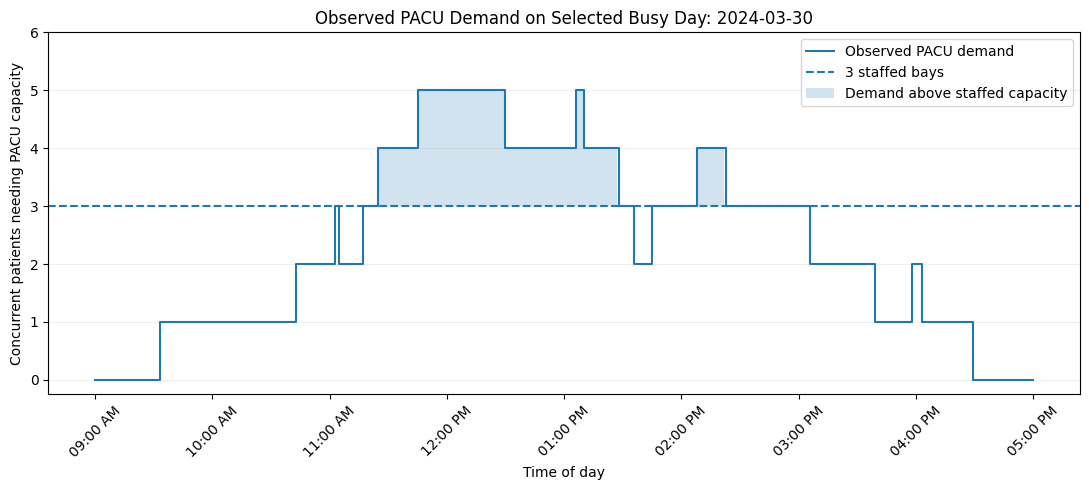

In [ ]:
capacity = 3

fig, ax = plt.subplots(figsize=(11, 5))

ax.step(
    observed_occupancy["time"],
    observed_occupancy["occupancy"],
    where="post",
    label="Observed PACU demand"
)

ax.axhline(
    capacity,
    linestyle="--",
    label="3 staffed bays"
)

ax.fill_between(
    observed_occupancy["time"],
    capacity,
    observed_occupancy["occupancy"],
    where=observed_occupancy["occupancy"] > capacity,
    step="post",
    alpha=0.2,
    label="Demand above staffed capacity"
)

ax.set_title(f"Observed PACU Demand on Selected Busy Day: {busy_day}")
ax.set_xlabel("Time of day")
ax.set_ylabel("Concurrent patients needing PACU capacity")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%I:%M %p"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=1))

max_occupancy = int(observed_occupancy["occupancy"].max())
ax.set_yticks(range(0, max_occupancy + 2))

ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
capacity = 3

observed_occupancy["excess_over_3"] = (
    observed_occupancy["occupancy"] - capacity
).clip(lower=0)

observed_peak_demand = observed_occupancy["occupancy"].max()
observed_any_over_3 = (observed_occupancy["occupancy"] > capacity).any()
observed_minutes_over_3 = (observed_occupancy["occupancy"] > capacity).sum()
observed_excess_patient_minutes_over_3 = observed_occupancy["excess_over_3"].sum()

print("Busy day:", busy_day)
print("Case count:", len(busy_day_df))
print("Observed peak timestamp-based demand:", observed_peak_demand)
print("Any demand over 3 staffed bays:", observed_any_over_3)
print("Minutes with demand over 3 staffed bays:", observed_minutes_over_3)
print("Excess patient-minutes over 3 staffed bays:", observed_excess_patient_minutes_over_3)

Busy day: 2024-03-30
Case count: 10
Observed peak timestamp-based demand: 5
Any demand over 3 staffed bays: True
Minutes with demand over 3 staffed bays: 138
Excess patient-minutes over 3 staffed bays: 187


### Observed Busy-Day Capacity Pressure

The reconstructed occupancy curve represents **timestamp-based PACU demand**: the number of cases whose recorded PACU intervals overlap at each point in time.

It should not be interpreted as proof that patients physically occupied more bays than the PACU could provide. When estimated demand exceeds the 3 staffed-bay assumption, the excess represents operational capacity pressure that could require temporary staffing, holding, boarding, delayed transfer, or another workflow response.

On the selected busy day, recorded case timing created demand above 3 staffed bays. This makes the schedule useful for stress testing. The Monte Carlo simulation keeps these PACU arrival times fixed while varying PACU LOS to estimate how consistently the schedule creates capacity pressure.

## Monte Carlo Simulation
### Purpose of the Monte Carlo Simulation

The purpose of the Monte Carlo simulation is to estimate how often a short-staffed PACU day would exceed 3 staffed bays under realistic variation in PACU length of stay.

For the simulation, I keep the selected busy day’s PACU arrival times fixed because those arrivals represent the known case schedule. I then repeatedly resample PACU LOS values from the full observed dataset to create many possible versions of the same day. Each simulated day produces a timestamp-based PACU demand curve.

This allows me to estimate the risk of demand exceeding 3 staffed bays, the expected number of minutes over capacity, and the typical or P90 peak PACU demand. These outputs support a simple staffing trigger rule for when temporary PACU support should be activated before capacity pressure occurs.

In [ ]:
np.random.seed(42)

n_sims = 5000
capacity = 3

arrival_times = (
    busy_day_df["or_pacu_arrival_dttm"]
    .sort_values()
    .reset_index(drop=True)
)

los_pool = or_df["pacu_los_minutes"].dropna().values

simulation_results = []

for sim in tqdm(range(n_sims), desc="Running simulations"):
    sampled_los = np.random.choice(los_pool, size=len(arrival_times), replace=True)
    discharge_times = arrival_times + pd.to_timedelta(sampled_los, unit="m")

    # Create event table: +1 at arrival, -1 at discharge
    events = pd.DataFrame({
        "time": pd.concat([arrival_times, discharge_times], ignore_index=True),
        "change": [1] * len(arrival_times) + [-1] * len(discharge_times)
    })

    # Combine events at same timestamp and sort
    events = (
        events
        .groupby("time", as_index=False)["change"]
        .sum()
        .sort_values("time")
        .reset_index(drop=True)
    )

    occupancy = 0
    peak_occupancy = 0
    minutes_over_3 = 0
    excess_patient_minutes_over_3 = 0

    for i in range(len(events) - 1):
        occupancy += events.loc[i, "change"]
        peak_occupancy = max(peak_occupancy, occupancy)

        current_time = events.loc[i, "time"]
        next_time = events.loc[i + 1, "time"]
        duration_minutes = (next_time - current_time).total_seconds() / 60

        if occupancy > capacity:
            minutes_over_3 += duration_minutes
            excess_patient_minutes_over_3 += (occupancy - capacity) * duration_minutes

    # Apply final event for peak check
    occupancy += events.loc[len(events) - 1, "change"]
    peak_occupancy = max(peak_occupancy, occupancy)

    simulation_results.append({
        "sim": sim + 1,
        "peak_occupancy": peak_occupancy,
        "exceeded_3": peak_occupancy > capacity,
        "minutes_over_3": minutes_over_3,
        "excess_patient_minutes_over_3": excess_patient_minutes_over_3
    })

sim_results_df = pd.DataFrame(simulation_results)

sim_results_df.head()

Running simulations:   0%|          | 0/5000 [00:00<?, ?it/s]

,sim,peak_occupancy,exceeded_3,minutes_over_3,excess_patient_minutes_over_3
0,1,5,True,92.0,109.0
1,2,5,True,88.0,130.0
2,3,5,True,164.0,229.0
3,4,4,True,37.0,37.0
4,5,6,True,51.0,92.0


### Simulation Result Summary

In [ ]:
prob_exceed_3 = sim_results_df["exceeded_3"].mean()
expected_minutes_over_3 = sim_results_df["minutes_over_3"].mean()
expected_excess_patient_minutes = sim_results_df["excess_patient_minutes_over_3"].mean()

median_peak = sim_results_df["peak_occupancy"].median()
p90_peak = sim_results_df["peak_occupancy"].quantile(0.90)

print(f"Simulation count: {n_sims}")
print(f"Probability of exceeding 3 staffed bays: {prob_exceed_3:.1%}")
print(f"Expected minutes over 3 staffed bays: {expected_minutes_over_3:.1f}")
print(f"Expected excess patient-minutes over 3 staffed bays: {expected_excess_patient_minutes:.1f}")
print(f"Median peak timestamp-based demand: {median_peak:.0f}")
print(f"P90 peak timestamp-based demand: {p90_peak:.0f}")

Simulation count: 5000
Probability of exceeding 3 staffed bays: 99.4%
Expected minutes over 3 staffed bays: 78.0
Expected excess patient-minutes over 3 staffed bays: 108.5
Median peak timestamp-based demand: 5
P90 peak timestamp-based demand: 6


### Simulation Visualization

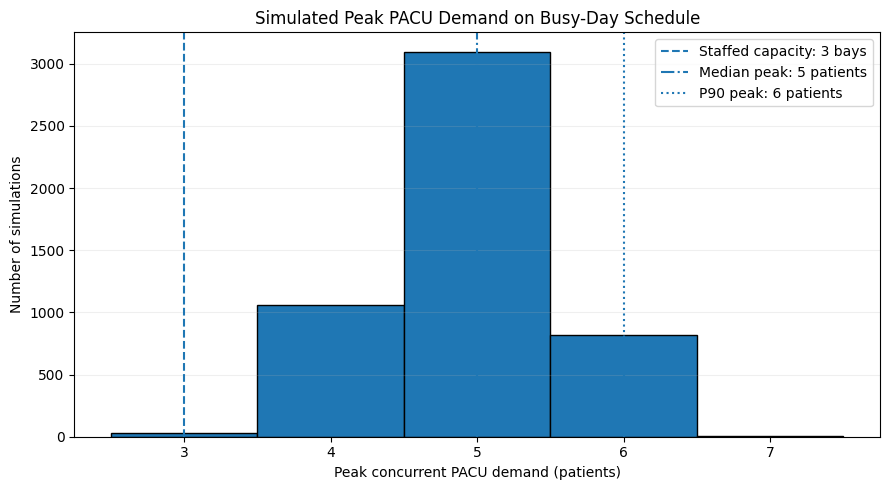

In [ ]:
median_peak = sim_results_df["peak_occupancy"].median()
p90_peak = sim_results_df["peak_occupancy"].quantile(0.90)

peak_min = int(sim_results_df["peak_occupancy"].min())
peak_max = int(sim_results_df["peak_occupancy"].max())

bins = np.arange(peak_min - 0.5, peak_max + 1.5, 1)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    sim_results_df["peak_occupancy"],
    bins=bins,
    edgecolor="black"
)

ax.axvline(
    3,
    linestyle="--",
    label="Staffed capacity: 3 bays"
)

ax.axvline(
    median_peak,
    linestyle="-.",
    label=f"Median peak: {median_peak:.0f} patients"
)

ax.axvline(
    p90_peak,
    linestyle=":",
    label=f"P90 peak: {p90_peak:.0f} patients"
)

ax.set_title("Simulated Peak PACU Demand on Busy-Day Schedule")
ax.set_xlabel("Peak concurrent PACU demand (patients)")
ax.set_ylabel("Number of simulations")

ax.set_xticks(range(peak_min, peak_max + 1))
ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

### Simulation Results: 3-Bay Short-Staffed Scenario

Using the selected busy-day PACU arrival schedule, I ran 5,000 Monte Carlo simulations. In each simulation, the PACU arrival times were held fixed and PACU LOS values were randomly resampled from the observed dataset.

The simulation showed a high probability of demand exceeding 3 staffed PACU bays. Across 5,000 simulated versions of the day:

- Probability of exceeding 3 staffed bays: 99.4%
- Expected minutes over 3 staffed bays: 79.6 minutes
- Expected excess patient-minutes over 3 staffed bays: 110.4
- Median peak timestamp-based PACU demand: 5 patients
- P90 peak timestamp-based PACU demand: 6 patients

These results suggest that this scheduled case pattern creates a very high risk of short-staffed PACU capacity pressure. Under a 3-bay staffing assumption, temporary PACU support should be activated for this type of day.

### Proposed Staffing Trigger Rule

Activate temporary PACU staffing when the simulated probability of exceeding 3 staffed bays is at least 75%.

I selected 75% as a practical high-risk threshold for a short-staffed PACU day. At this level, demand exceeds staffed capacity in at least three out of four simulated versions of the schedule. This is high enough to distinguish persistent capacity risk from occasional overlap while still allowing PACU and OR leaders to respond before the expected demand cluster occurs.

For the selected busy-day schedule, the simulated probability of exceeding 3 staffed bays was 99.4%, which is well above the 75% trigger threshold. Therefore, this day would clearly qualify for temporary PACU staffing support.

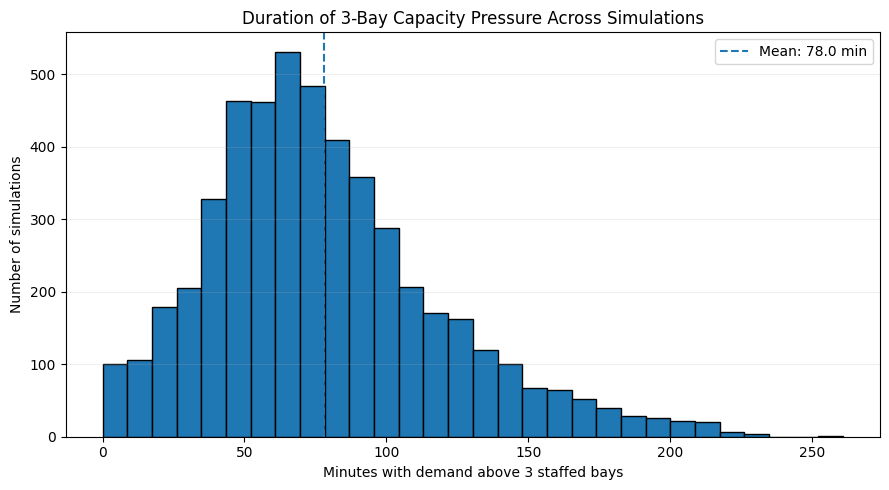

In [ ]:
mean_minutes_over = sim_results_df["minutes_over_3"].mean()

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    sim_results_df["minutes_over_3"],
    bins=30,
    edgecolor="black"
)

ax.axvline(
    mean_minutes_over,
    linestyle="--",
    label=f"Mean: {mean_minutes_over:.1f} min"
)

ax.set_title("Duration of 3-Bay Capacity Pressure Across Simulations")
ax.set_xlabel("Minutes with demand above 3 staffed bays")
ax.set_ylabel("Number of simulations")

ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

### Case-Count Screening Analysis

The primary staffing rule uses schedule-specific simulated over-capacity risk. As a supporting analysis, I also screened all observed PACU days to determine whether daily case count could serve as a simple early warning signal.

For each observed day, PACU arrival times were held fixed and LOS was resampled 1,000 times. This screening analysis estimates the probability that peak PACU demand exceeds 3 staffed bays. It is intended to show how risk generally changes with daily volume, not to replace the schedule-specific staffing simulation.

In [ ]:
# Fast screening simulation by observed PACU day
# Purpose: estimate 3-bay over-capacity risk by daily case count
# This is faster than the full event-based simulation because it only calculates peak demand.

# -----------------------------
# Settings
# -----------------------------
rng = np.random.default_rng(42)

capacity = 3
n_sims_screen = 1000   # use 500 for faster testing; 1000 is fine for final screening

# LOS pool from full observed dataset
los_pool_screen = or_df["pacu_los_minutes"].dropna().values


# -----------------------------
# Fast simulation function
# -----------------------------
def quick_peak_risk_simulation(arrival_times, los_pool, capacity=3, n_sims=1000, rng=None):
    """
    Fast Monte Carlo screen for one PACU day.

    Keeps PACU arrival times fixed.
    Randomly samples PACU LOS values.
    Calculates whether peak timestamp-based demand exceeds staffed capacity.

    This is meant for screening many days quickly.
    It estimates probability of exceeding capacity and peak demand,
    but it does not calculate minutes over capacity.
    """

    if rng is None:
        rng = np.random.default_rng(42)

    # Convert arrival times to minute offsets from first arrival
    arrival_times = pd.to_datetime(pd.Series(arrival_times)).sort_values().reset_index(drop=True)
    arrival_minutes = (
        (arrival_times - arrival_times.min())
        .dt.total_seconds()
        .to_numpy() / 60
    )

    n_cases = len(arrival_minutes)

    # If a day has no cases, return empty-safe values
    if n_cases == 0:
        return {
            "sim_probability_exceeding_3": np.nan,
            "median_peak_demand": np.nan,
            "p90_peak_demand": np.nan
        }

    # Sample LOS matrix: rows = simulations, columns = cases
    sampled_los = rng.choice(
        los_pool,
        size=(n_sims, n_cases),
        replace=True
    )

    # Simulated discharge time in minutes
    discharge_minutes = arrival_minutes.reshape(1, -1) + sampled_los

    # Peak demand only needs to be checked at arrival times.
    # For each simulation and each arrival time:
    # occupancy = arrivals so far - discharges already completed
    discharged_by_arrival = (
        discharge_minutes[:, :, None] <= arrival_minutes.reshape(1, 1, -1)
    ).sum(axis=1)

    arrivals_so_far = np.arange(1, n_cases + 1).reshape(1, -1)
    occupancy_at_arrivals = arrivals_so_far - discharged_by_arrival

    peak_demand = occupancy_at_arrivals.max(axis=1)

    return {
        "sim_probability_exceeding_3": (peak_demand > capacity).mean(),
        "median_peak_demand": np.median(peak_demand),
        "p90_peak_demand": np.quantile(peak_demand, 0.90)
    }


# -----------------------------
# Run fast simulation for each observed PACU day
# -----------------------------
daily_screen_results = []

for pacu_date, day_df in tqdm(or_df.groupby("pacu_arrival_date"), desc="Screening observed PACU days"):

    case_count = len(day_df)

    result = quick_peak_risk_simulation(
        arrival_times=day_df["or_pacu_arrival_dttm"],
        los_pool=los_pool_screen,
        capacity=capacity,
        n_sims=n_sims_screen,
        rng=rng
    )

    daily_screen_results.append({
        "pacu_arrival_date": pacu_date,
        "case_count": case_count,
        **result
    })

daily_screen_df = pd.DataFrame(daily_screen_results)

daily_screen_df.head()

Screening observed PACU days:   0%|          | 0/341 [00:00<?, ?it/s]

,pacu_arrival_date,case_count,sim_probability_exceeding_3,median_peak_demand,p90_peak_demand
0,2024-01-01,1,0.0,1.0,1.0
1,2024-01-02,4,0.0,2.0,2.0
2,2024-01-03,5,0.0,2.0,3.0
3,2024-01-05,1,0.0,1.0,1.0
4,2024-01-06,2,0.0,1.0,2.0


In [ ]:
risk_by_case_count = (
    daily_screen_df
    .groupby("case_count")
    .agg(
        days=("pacu_arrival_date", "count"),
        mean_risk=("sim_probability_exceeding_3", "mean"),
        median_risk=("sim_probability_exceeding_3", "median"),
        p25_risk=("sim_probability_exceeding_3", lambda x: x.quantile(0.25)),
        p75_risk=("sim_probability_exceeding_3", lambda x: x.quantile(0.75)),
        max_risk=("sim_probability_exceeding_3", "max"),
        median_peak=("median_peak_demand", "median"),
        median_p90_peak=("p90_peak_demand", "median")
    )
    .reset_index()
)

risk_by_case_count

,case_count,days,mean_risk,median_risk,p25_risk,p75_risk,max_risk,median_peak,median_p90_peak
0,1,66,0.000000,0.0000,0.0000,0.0000,0.000,1.0,1.0
1,2,85,0.000000,0.0000,0.0000,0.0000,0.000,1.0,2.0
2,3,78,0.000000,0.0000,0.0000,0.0000,0.000,2.0,2.0
3,4,53,0.015434,0.0000,0.0000,0.0000,0.194,2.0,2.0
4,5,28,0.091821,0.0015,0.0000,0.0505,0.801,3.0,3.0
5,6,17,0.144765,0.0740,0.0000,0.1170,0.672,3.0,3.0
6,7,7,0.177714,0.1270,0.0535,0.2890,0.432,3.0,4.0
7,8,3,0.716000,0.8270,0.5895,0.8980,0.969,4.0,4.0
8,9,3,0.875333,0.8320,0.8300,0.8990,0.966,4.0,5.0
9,10,1,0.991000,0.9910,0.9910,0.9910,0.991,5.0,6.0


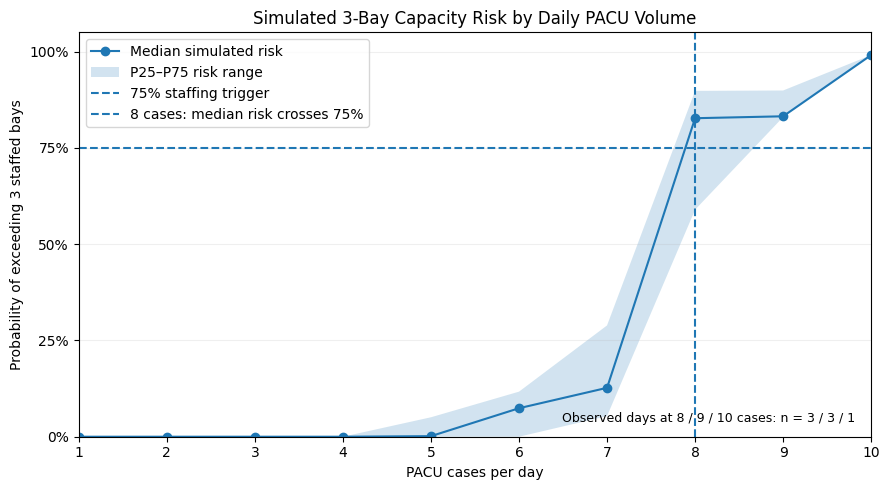

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    risk_by_case_count["case_count"],
    risk_by_case_count["median_risk"],
    marker="o",
    label="Median simulated risk"
)

ax.fill_between(
    risk_by_case_count["case_count"],
    risk_by_case_count["p25_risk"],
    risk_by_case_count["p75_risk"],
    alpha=0.2,
    label="P25–P75 risk range"
)

ax.axhline(
    0.75,
    linestyle="--",
    label="75% staffing trigger"
)

ax.axvline(
    8,
    linestyle="--",
    label="8 cases: median risk crosses 75%"
)

ax.set_title("Simulated 3-Bay Capacity Risk by Daily PACU Volume")
ax.set_xlabel("PACU cases per day")
ax.set_ylabel("Probability of exceeding 3 staffed bays")

ax.set_xticks(range(1, 11))
ax.set_xlim(1, 10)

risk_ticks = np.arange(0, 1.01, 0.25)
ax.set_yticks(risk_ticks)
ax.set_yticklabels([f"{value:.0%}" for value in risk_ticks])
ax.set_ylim(0, 1.05)

ax.text(
    0.98,
    0.03,
    "Observed days at 8 / 9 / 10 cases: n = 3 / 3 / 1",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9
)

ax.grid(axis="y", alpha=0.2)
ax.legend()

plt.tight_layout()
plt.show()

## Recommendation and Operational Use

Based on the simulation results, I recommend using the following staffing trigger rule:

> **On short-staffed PACU days with only 3 staffed bays, activate temporary PACU staffing when the simulated probability of exceeding 3 staffed bays is at least 75%.**

This rule should be applied before or early in the day using the expected PACU arrival schedule. The simulation keeps the scheduled PACU arrival times fixed and repeatedly resamples PACU length of stay from the observed dataset. The output is the estimated probability that timestamp-based PACU demand will exceed 3 staffed bays at least once during the day.

For the selected busy-day schedule, the simulation estimated a **99.4% probability** of exceeding 3 staffed PACU bays. The expected time over 3 bays was **79.6 minutes**, the median peak demand was **5 patients**, and the P90 peak demand was **6 patients**. Since the simulated risk is well above the 75% trigger threshold, this day would clearly qualify for temporary PACU staffing.

Daily case count can also be used as an early screening signal, but it should not be treated as a staffing trigger by itself. Median simulated risk remained relatively low for most 5- to 7-case schedules, but individual days varied substantially because arrival clustering affects how many patients require PACU capacity at the same time. For example, one observed 5-case schedule exceeded the 75% simulated-risk threshold despite the low median risk for 5-case days.

In this dataset, median simulated risk first exceeded the 75% trigger at 8 cases per day. However, only three observed days had 8 cases, three had 9 cases, and one had 10 cases, so these case-count results should be treated as descriptive screening guidance rather than validated thresholds. The final staffing decision should come from the schedule-specific simulation because PACU arrival timing and overlap drive capacity pressure.

In plain language: if the day’s scheduled PACU arrivals create a high simulated chance of needing more than 3 staffed bays, leaders should activate temporary support before the expected busy PACU arrival period rather than waiting until PACU is already over capacity.

### Caveat

This simulation estimates timestamp-based PACU demand, not literal physical occupancy beyond the PACU’s real-world maximum. If demand exceeds 3 staffed bays, the result should be interpreted as capacity pressure that may require temporary staffing, holding, delayed transfer, or other operational workarounds. The model also assumes that the observed PACU length-of-stay distribution is a reasonable estimate for future short-staffed days.